In [189]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import json
sns.set_style("whitegrid")

In [190]:
df = pd.read_csv("data/youtube_videos.csv")

In [191]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


## MinMax

In [192]:
df["subscribers"]

0       441016
1        25339
2      2398429
3       498144
4        30039
        ...   
205      13428
206      10005
207     483919
208      11937
209     553531
Name: subscribers, Length: 210, dtype: int64

In [193]:
scaler = MinMaxScaler()

In [194]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [195]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

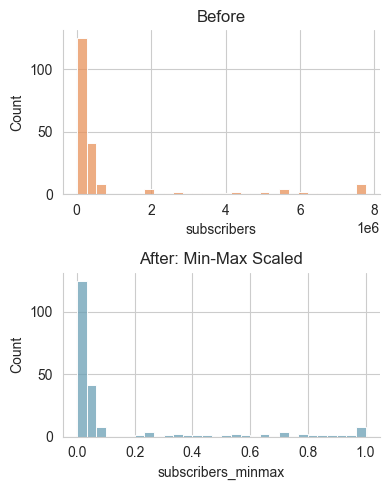

In [196]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["subscribers"], 
             ax=axes[0], 
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("subscribers")

sns.histplot(df["subscribers_minmax"], 
             ax=axes[1], 
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("subscribers_minmax")

sns.despine()
plt.tight_layout()
plt.show()

In [197]:
df["views_minmax"] = scaler.fit_transform(df[["views"]])

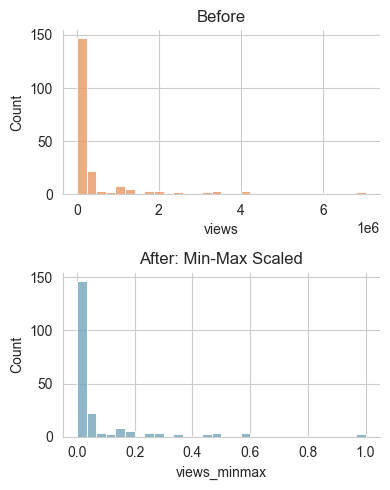

In [198]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"], 
             ax=axes[0], 
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("views")

sns.histplot(df["views_minmax"], 
             ax=axes[1], 
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("views_minmax")

sns.despine()
plt.tight_layout()
plt.show()

## Z-Score

In [199]:
standard_scaler = StandardScaler()

In [200]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [201]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


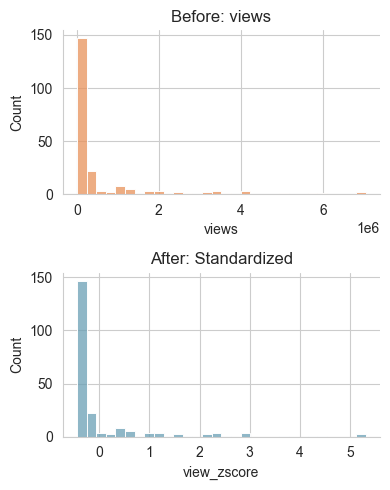

In [202]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["view_zscore"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Standardized")
axes[1].set_xlabel("view_zscore")

sns.despine()
plt.tight_layout()
plt.show()

In [203]:
df["comments_zscore"] = standard_scaler.fit_transform(df[["comments"]])

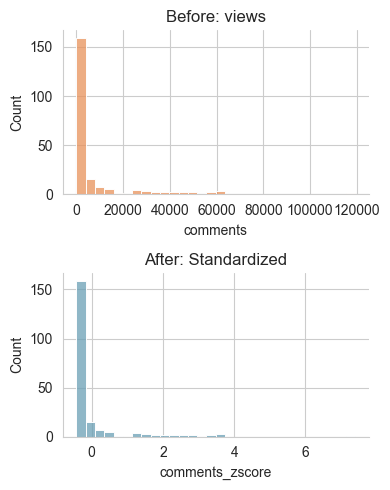

In [204]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["comments"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("comments")

sns.histplot(df["comments_zscore"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Standardized")
axes[1].set_xlabel("comments_zscore")

sns.despine()
plt.tight_layout()
plt.show()

## Robust Scaling

In [205]:
robust_scaler = RobustScaler()

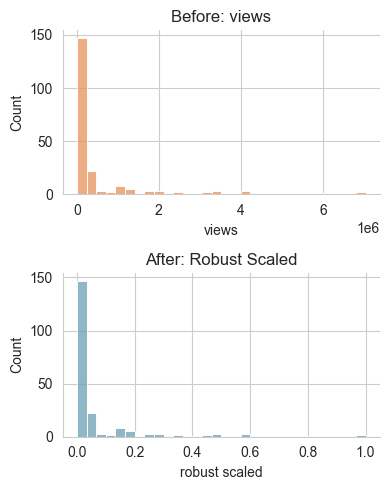

In [206]:
df["views_robust"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

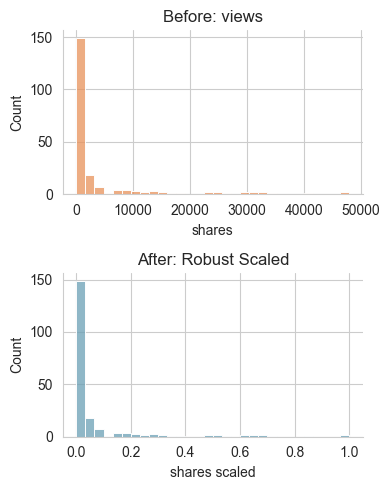

In [207]:
df["shares_robust"] = scaler.fit_transform(df[["shares"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["shares"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("shares")

sns.histplot(df["shares_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("shares scaled")

sns.despine()
plt.tight_layout()
plt.show()

## Log Transform

In [208]:
df["views_log"] = np.log1p(df["views"])

In [209]:
df["views_log"]

0      12.337553
1      10.129786
2      14.096130
3      12.142883
4       9.440181
         ...    
205     8.770594
206     8.467162
207    11.560315
208     8.015327
209    11.884806
Name: views_log, Length: 210, dtype: float64

<Axes: xlabel='views_log', ylabel='Count'>

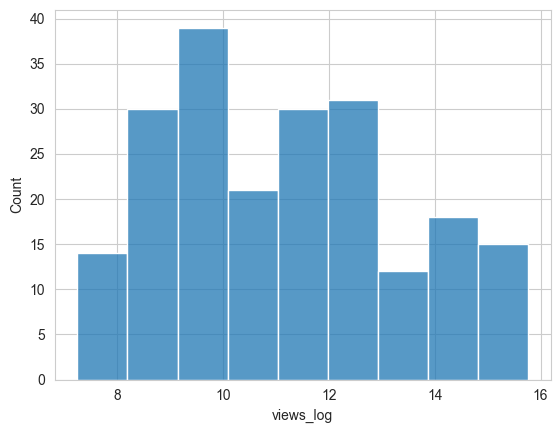

In [210]:
sns.histplot(df["views_log"])

<Axes: xlabel='views', ylabel='Count'>

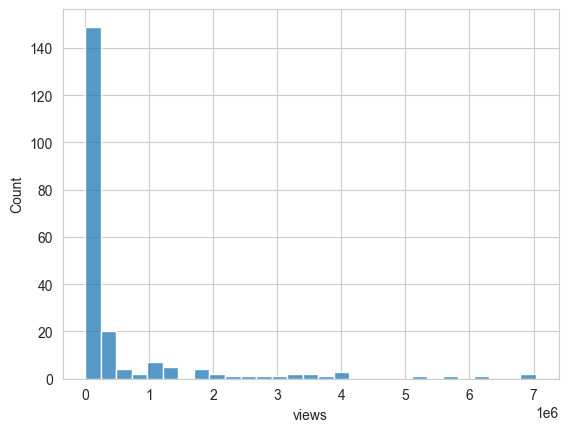

In [211]:
sns.histplot(df["views"])

In [212]:
df["subscribers_log"] = np.log1p(df["subscribers"])

<Axes: xlabel='subscribers_log', ylabel='Count'>

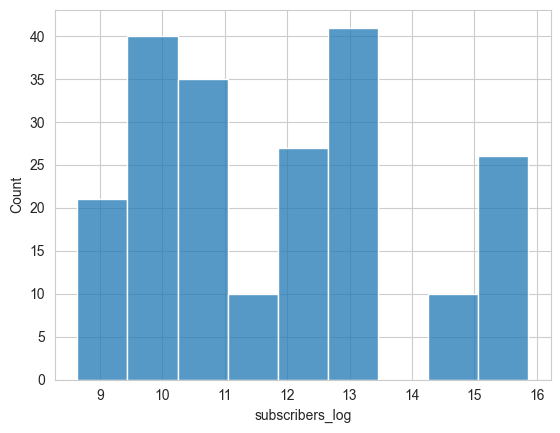

In [213]:
sns.histplot(df["subscribers_log"])

<Axes: xlabel='subscribers', ylabel='Count'>

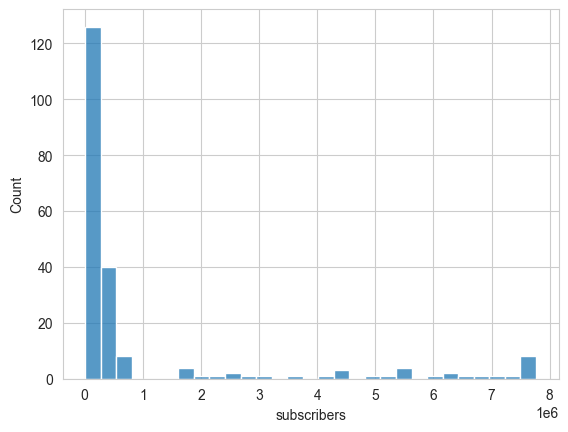

In [214]:
sns.histplot(df["subscribers"])

## Binning

In [215]:
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

<Axes: xlabel='duration_bin', ylabel='count'>

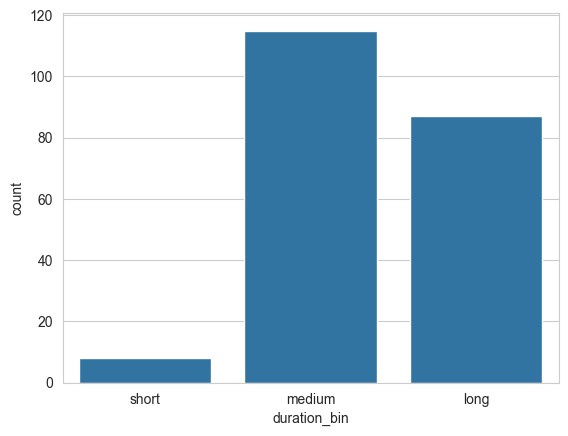

In [216]:
sns.countplot(x="duration_bin", data=df)

<Axes: xlabel='likes_bin', ylabel='count'>

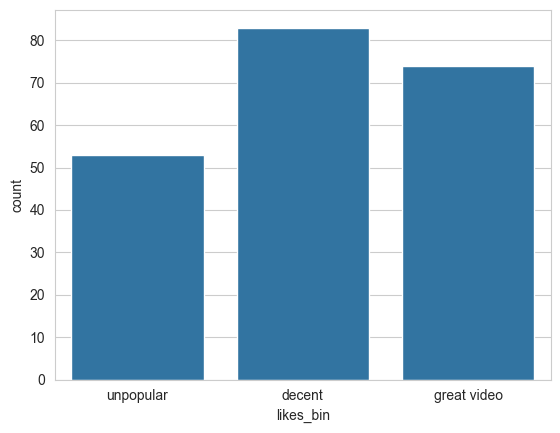

In [217]:
bins = [0, 500, 5000, float("inf")]
labels = ["unpopular", "decent", "great video"]

df["likes_bin"] = pd.cut(df["likes"], bins=bins, labels=labels)

sns.countplot(x="likes_bin", data=df)

## Ordinal Endcoding

In [218]:
df["channel_tier"].unique()

<StringArray>
['Mid', 'Small', 'Large']
Length: 3, dtype: str

In [219]:
encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [220]:
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


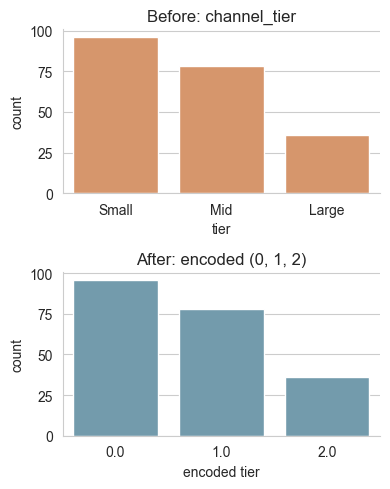

In [221]:
enc = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df["channel_tier_encoded"] = enc.fit_transform(
    df[["channel_tier"]]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

order_str = ["Small", "Mid", "Large"]
sns.countplot(data=df,
              x="channel_tier",
              order=order_str,
              color="#e8925a",
              ax=axes[0])
axes[0].set_title("Before: channel_tier")
axes[0].set_xlabel("tier")

order_num = [0, 1, 2]
sns.countplot(data=df,
              x="channel_tier_encoded",
              color="#6a9fb5",
              ax=axes[1])
axes[1].set_title("After: encoded (0, 1, 2)")
axes[1].set_xlabel("encoded tier")

sns.despine()
plt.tight_layout()
plt.show()

## One-Hot Encoding

In [222]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [223]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [224]:
df = pd.concat([df, dummyVars], axis=1)

In [225]:
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,subscribers_log,duration_bin,likes_bin,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,12.996839,medium,great video,1.0,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,10.140139,medium,decent,0.0,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,14.690325,medium,great video,2.0,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,13.118646,medium,decent,1.0,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,10.310285,long,decent,0.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,9.505172,medium,unpopular,0.0,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,9.210940,long,unpopular,0.0,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,13.089675,long,decent,1.0,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,9.387482,long,unpopular,0.0,True,False,False,False,False,False


## Date & Time

In [226]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [227]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[us]

In [228]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

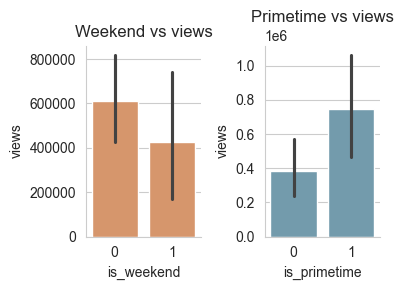

In [229]:
# extract features from timestamp
df["is_weekend"] = (df["uploaded_at"].dt.dayofweek >= 5).astype(int)
df["is_primetime"] = (
    (df["uploaded_at"].dt.hour >= 18) &
    (df["uploaded_at"].dt.hour <= 22)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))

sns.barplot(data=df,
            x="is_weekend",
            y="views",
            color="#e8925a",
            ax=axes[0])
axes[0].set_title("Weekend vs views")
axes[0].set_xlabel("is_weekend")

sns.barplot(data=df,
            x="is_primetime",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("Primetime vs views")
axes[1].set_xlabel("is_primetime")

sns.despine()
plt.tight_layout()
plt.show()

## CAPS and Lower Counts

In [230]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

df["lower_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.islower())
)

In [231]:
df[["caps_count", "lower_count"]]

,caps_count,lower_count
0,3,6
1,1,6
2,0,7
3,0,3
4,4,5
...,...,...
205,3,6
206,2,9
207,0,4
208,2,9


In [232]:
def countCaps(t):
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum = sum+1
    return sum

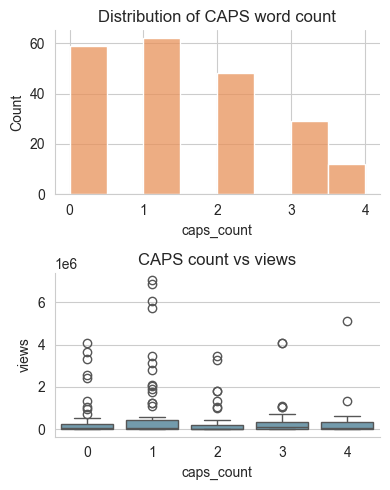

In [233]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["caps_count"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df,
            x="caps_count",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

sns.despine()
plt.tight_layout()
plt.show()

## TF-IDF

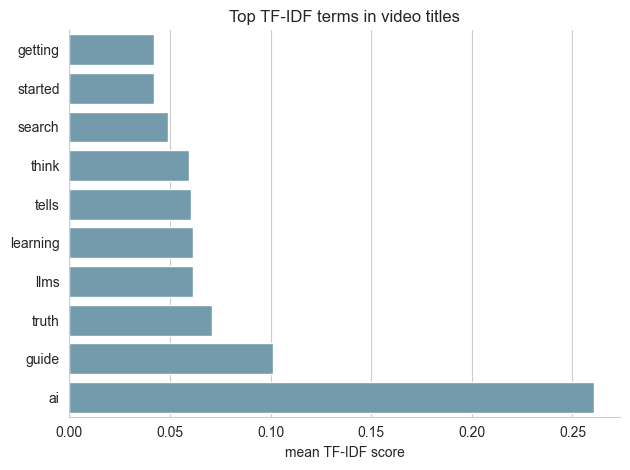

In [234]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

## Retention Rate

In [235]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"]* df["duration_minutes"])

In [236]:
df["retention_rate"]

0      0.398058
1      0.535375
2      0.415428
3      0.483146
4      0.396453
         ...   
205    0.469772
206    0.289126
207    0.495605
208    0.528993
209    0.434620
Name: retention_rate, Length: 210, dtype: float64

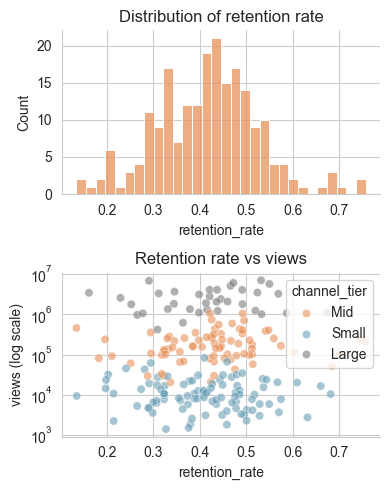

In [237]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

## Interaction Features

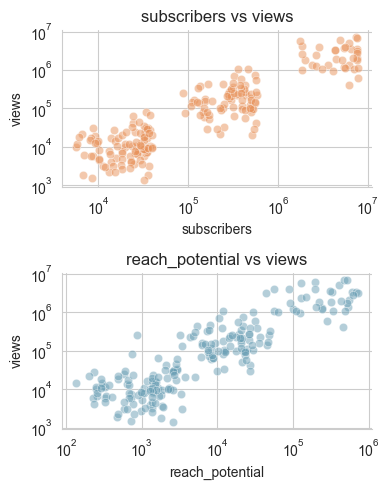

In [238]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

## Multi-Label Encoding

In [239]:
df["hashtags"] = df["hashtags"].apply(json.loads)

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
